In [1]:
import os
import pandas as pd
import numpy as np
import pylab as plt
import seaborn as sns
from adjustText import adjust_text

In [2]:
%load_ext autoreload
%autoreload 2
import src.count_utils as utils

In [3]:
import jupyter_black
jupyter_black.load()

In [4]:
plt.style.use("../src/mpl_style.txt")

### Subgroup Analysis on Countries

In [5]:
sections = ["abstract", "introduction", "methods", "results", "discussion", "full"]
colors = dict(zip(sections, sns.color_palette("colorblind", len(sections))))
# change full color to make it less similar to introduction
colors["full"] = (0.541, 0.365, 0.224)

In [6]:
VERSION = "research-article_aimrd_f"
BASELINE = "baseline_2026-01-23"
RESULTS_PATH = os.path.join("../data/results/", BASELINE, VERSION)
secs = next(os.walk(RESULTS_PATH))[1]

CUTOFF_VERSION = "opt"

In [7]:
freqs_dfs = {}

for sec in ["abstract", "full"]:
    freqs_dfs[sec] = utils.get_country_frequency(RESULTS_PATH, sec, CUTOFF_VERSION)
    p = freqs_dfs[sec]["projection"]
    q = freqs_dfs[sec]["frequency"]
    totals = freqs_dfs[sec]["paper_counts"]
    reg_se = freqs_dfs[sec]["regression se"]
    freqs_dfs[sec]["regression se (ds)"] = list(
        map(utils.se, p, q, totals, ["regression"] * len(p), reg_se)
    )

loading country freqs
loading country freqs


In [8]:
freqs_dfs["full"][freqs_dfs["full"]["cutoff"] == "english"]

,cutoff,time,frequency,projection,diff,usage estimate,regression se,paper_counts,regression se (ds)
20,english,2018,0.989627,0.990081,-0.000453,-0.045682,0.000819,26897.0,0.106442
42,english,2019,0.991976,0.991051,0.000925,0.103353,0.000738,28539.0,0.094617
64,english,2020,0.991601,0.992022,-0.000421,-0.052778,0.000709,33336.0,0.112615
86,english,2021,0.992873,0.992993,-0.000120,-0.017118,0.000738,39425.0,0.123018
108,english,2022,0.994033,0.993963,0.000069,0.011476,0.000819,42899.0,0.147561
130,english,2023,0.994750,0.994934,-0.000184,-0.036237,0.000938,42479.0,0.203988
152,english,2024,0.996384,0.995905,0.000479,0.117074,0.001083,44249.0,0.243713
174,english,2025,0.997911,0.996875,0.001036,0.331577,0.001245,48358.0,0.274541


In [9]:
freqs_dfs["full"][freqs_dfs["full"]["cutoff"] == "non-english"]

,cutoff,time,frequency,projection,diff,usage estimate,regression se,paper_counts,regression se (ds)
21,non-english,2018,0.956970,0.955980,0.000990,0.022486,0.001761,56982.0,0.043617
43,non-english,2019,0.958561,0.958950,-0.000389,-0.009468,0.001588,62983.0,0.043569
65,non-english,2020,0.960023,0.961919,-0.001897,-0.049808,0.001525,76092.0,0.045998
87,non-english,2021,0.965889,0.964889,0.001000,0.028484,0.001588,89179.0,0.047215
109,non-english,2022,0.968154,0.967859,0.000295,0.009192,0.001761,99416.0,0.056990
131,non-english,2023,0.976344,0.970829,0.005515,0.189066,0.002018,86869.0,0.058810
153,non-english,2024,0.987526,0.973798,0.013727,0.523905,0.002330,89943.0,0.044629
175,non-english,2025,0.995359,0.976768,0.018590,0.800209,0.002678,97166.0,0.024872


In [10]:
freqs_dfs["full"][freqs_dfs["full"]["cutoff"] == "Canada"]

,cutoff,time,frequency,projection,diff,usage estimate,regression se,paper_counts,regression se (ds)
6,Canada,2018,0.989639,0.991893,-0.002253,-0.277914,0.002667,2412.0,0.491258
28,Canada,2019,0.995210,0.992576,0.002634,0.354772,0.002404,2504.0,0.279599
50,Canada,2020,0.994039,0.993259,0.000781,0.115798,0.002309,2851.0,0.370774
72,Canada,2021,0.993491,0.993942,-0.000451,-0.074363,0.002404,3379.0,0.483554
94,Canada,2022,0.993914,0.994625,-0.000711,-0.132256,0.002667,3778.0,0.609015
116,Canada,2023,0.993813,0.995308,-0.001494,-0.318475,0.003055,3555.0,0.902983
138,Canada,2024,0.998157,0.995991,0.002167,0.540424,0.003528,3798.0,0.440026
160,Canada,2025,0.997812,0.996674,0.001138,0.342160,0.004055,4112.0,0.831335


In [11]:
freqs_dfs["full"][freqs_dfs["full"]["cutoff"] == "Taiwan"]

,cutoff,time,frequency,projection,diff,usage estimate,regression se,paper_counts,regression se (ds)
16,Taiwan,2018,0.951318,0.950964,0.000354,0.007223,0.003617,985.0,0.157847
38,Taiwan,2019,0.952336,0.954979,-0.002644,-0.058719,0.003260,1048.0,0.165067
60,Taiwan,2020,0.962929,0.958994,0.003935,0.095973,0.003132,1105.0,0.154855
82,Taiwan,2021,0.961652,0.963009,-0.001357,-0.036683,0.003260,1355.0,0.168039
104,Taiwan,2022,0.966735,0.967024,-0.000289,-0.008768,0.003617,1472.0,0.179810
126,Taiwan,2023,0.978059,0.971039,0.007021,0.242409,0.004144,1184.0,0.182638
148,Taiwan,2024,0.992976,0.975053,0.017923,0.718450,0.004785,1138.0,0.112977
170,Taiwan,2025,0.996127,0.979068,0.017059,0.814971,0.005500,1290.0,0.095862


In [12]:
country_alt_names = {
    "United States of America": "USA",
    "United Kingdom of Great Britain and Northern Ireland": "UK",
    "Korea, Republic of": "South Korea",
    "Iran, Islamic Republic of": "Iran",
    "english": "NES",
    "non-english": "NNES",
}

In [13]:
df = pd.concat(freqs_dfs, names=["section"]).reset_index(level=0).reset_index(drop=True)
df["country"] = [
    country_alt_names[c] if c in country_alt_names.keys() else c for c in df["cutoff"]
]
df = df.drop("cutoff", axis=1)
df["section"] = pd.Categorical(
    df["section"],
    categories=[
        "abstract",
        "introduction",
        "methods",
        "results",
        "discussion",
        "full",
    ],
    ordered=True,
)
df

,section,time,frequency,projection,diff,usage estimate,regression se,paper_counts,regression se (ds),country
0,abstract,2018,0.833751,0.831380,0.002371,0.014062,0.006490,16366.0,0.041687,China
1,abstract,2018,0.896848,0.893131,0.003717,0.034778,0.005556,15384.0,0.055178,USA
2,abstract,2018,0.896898,0.891130,0.005768,0.052982,0.006940,6478.0,0.069632,UK
3,abstract,2018,0.796324,0.796959,-0.000635,-0.003127,0.004705,5385.0,0.035649,Japan
4,abstract,2018,0.888269,0.892271,-0.004002,-0.037146,0.007683,4483.0,0.085896,Germany
...,...,...,...,...,...,...,...,...,...,...
347,full,2025,0.996888,0.977931,0.018957,0.858986,0.023941,963.0,0.173252,Iran
348,full,2025,0.984333,0.919553,0.064780,0.805249,0.029241,1850.0,0.079368,Türkiye
349,full,2025,0.993243,0.982351,0.010892,0.617154,0.012952,887.0,0.321302,Poland
350,full,2025,0.997911,0.996875,0.001036,0.331577,0.001245,48358.0,0.274541,NES


In [14]:
exclude = ["Türkiye", "Poland"]
df_filtered = df[
    (df["time"].between(2022, 2025))
    & (df["section"].isin(["abstract", "full"]))
    & (~df["country"].isin(exclude))
]
df_filtered

,section,time,frequency,projection,diff,usage estimate,regression se,paper_counts,regression se (ds),country
88,abstract,2022,0.865600,0.861688,0.003912,0.028281,0.006490,36234.0,0.047399,China
89,abstract,2022,0.919416,0.915199,0.004216,0.049720,0.005556,26282.0,0.065333,USA
90,abstract,2022,0.907816,0.905872,0.001945,0.020658,0.006940,8200.0,0.079784,UK
91,abstract,2022,0.805621,0.804391,0.001230,0.006287,0.004705,7685.0,0.033223,Japan
92,abstract,2022,0.909818,0.909877,-0.000059,-0.000657,0.007683,7251.0,0.093111,Germany
...,...,...,...,...,...,...,...,...,...,...
345,full,2025,0.997100,0.992456,0.004644,0.615612,0.005981,2068.0,0.342676,Switzerland
346,full,2025,0.996127,0.979068,0.017059,0.814971,0.005500,1290.0,0.095862,Taiwan
347,full,2025,0.996888,0.977931,0.018957,0.858986,0.023941,963.0,0.173252,Iran
350,full,2025,0.997911,0.996875,0.001036,0.331577,0.001245,48358.0,0.274541,NES


In [15]:
countries_in_order = [
    "South Korea",
    "China",
    "Taiwan",
    "Iran",
    "Spain",
    "India",
    "Switzerland",
    "Brazil",
    "Italy",
    "Japan",
    "Germany",
    "Netherlands",
    "Sweden",
    "Canada",
    "Australia",
    "France",
    "USA",
    "UK",
    "NES",
    "NNES",
]

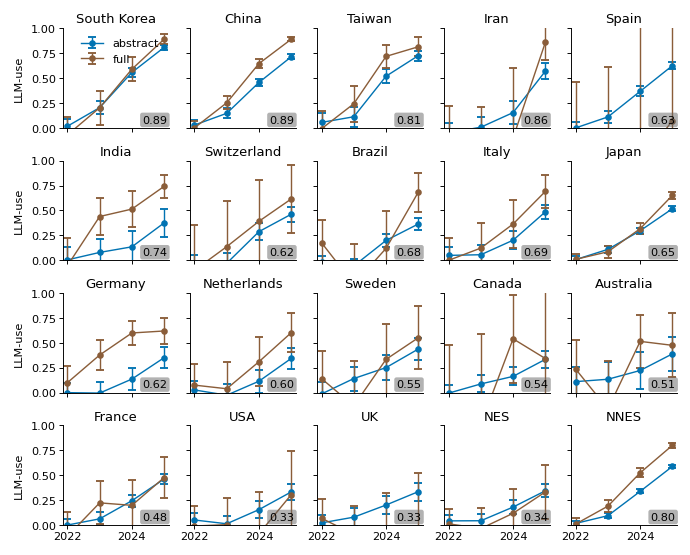

In [16]:
countries = df_filtered["country"].unique()
n = len(countries)

ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(ncols, nrows),
    sharex=True,
    sharey=True,
    layout="constrained",
)
axes = axes.flatten()

for i, country in enumerate(countries_in_order):
    ax = axes[i]
    sub = df_filtered[df_filtered["country"] == country]

    for section in ["abstract", "full"]:
        sec_data = sub[sub["section"] == section].sort_values("time")

        ax.errorbar(
            sec_data["time"],
            sec_data["usage estimate"],
            yerr=sec_data["regression se (ds)"],
            color=colors[section],
            marker="o",
            linestyle="-",
            capsize=2,
            markersize=2.5,
            clip_on=True,
            label=section,
        )

    # Title
    ax.set_title(country)

    # Max usage annotation
    max_usage = sub["usage estimate"].max()
    ax.text(
        0.75,  # 0.05,
        0.05,  # 0.9,
        f"{max_usage:.2f}",
        transform=ax.transAxes,
        bbox=dict(
            facecolor="#666666", edgecolor="none", alpha=0.5, boxstyle="round,pad=.2"
        ),
    )

    ax.set_ylim([0, 1])

    if i % ncols == 0:
        ax.set_ylabel("LLM-use")

axes[0].legend()

# plt.tight_layout()
plt.savefig(
    os.path.join(
        "../results/plots",
        BASELINE,
        VERSION,
        "countries_individual_{CUTOFF_VERSION}.png",
    ),
    dpi=300,
)
plt.show()

In [17]:
df_full = df[(df["section"] == "full") & (df["time"].isin([2024, 2025]))]
df_full = df_full.pivot(
    index="country", columns="time", values="usage estimate"
).reset_index()

In [18]:
english_countries = ["USA", "UK", "Canada", "Australia", "NES"]
df_full["group"] = [
    "NES" if c in english_countries else "NNES" for c in df_full["country"]
]

In [19]:
df_full["ha"] = [
    "left",
    "left",
    "right",
    "right",
    "right",
    "right",
    "right",
    "right",
    "right",
    "left",
    "left",
    "left",
    "right",
    "left",
    "left",
    "left",
    "left",
    "right",
    "left",
    "left",
    "right",
    "right",
]
# df_full["ha"] = ["right"] * len(df_full)
df_full["va"] = [
    "top",
    "top",
    "top",
    "bottom",
    "bottom",
    "bottom",
    "bottom",
    "bottom",
    "center",
    "bottom",
    "bottom",
    "bottom",
    "bottom",
    "bottom",
    "bottom",
    "top",
    "top",
    "top",
    "top",
    "top",
    "top",
    "bottom",
]
# df_full["va"] = ["top"] * len(df_full)
df_full

time,country,2024,2025,group,ha,va
0,Australia,0.514667,0.474933,NES,left,top
1,Brazil,0.118642,0.684126,NNES,left,top
2,Canada,0.540424,0.342160,NES,right,top
3,China,0.646239,0.890548,NNES,right,bottom
4,France,0.196901,0.476188,NNES,right,bottom
5,Germany,0.599142,0.619158,NNES,right,bottom
6,India,0.513926,0.742602,NNES,right,bottom
7,Iran,-0.100539,0.858986,NNES,right,bottom
8,Italy,0.364031,0.691735,NNES,right,center
9,Japan,0.317008,0.652155,NNES,left,bottom


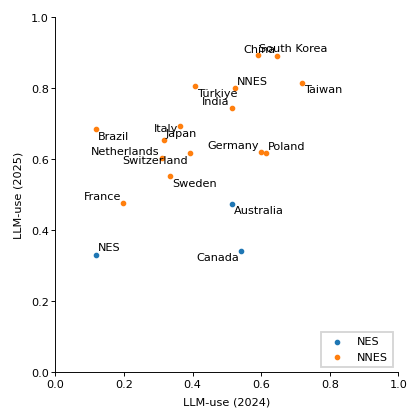

In [20]:
fig, ax = plt.subplots(
    figsize=(3, 3),
    layout="constrained",
)

for group, d in df_full.groupby("group"):
    ax.scatter(d[2024], d[2025], label=group)

for _, row in df_full.iterrows():
    x_offset = 1 if row["ha"] == "left" else -1
    y_offset = 1 if row["va"] == "bottom" else -1
    ax.annotate(
        row["country"],
        xy=(row[2024], row[2025]),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        ha=row["ha"],
        va=row["va"],
    )

ax.set_xlabel("LLM-use (2024)")
ax.set_ylabel("LLM-use (2025)")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.legend(loc="lower right", frameon=True)

plt.savefig(
    os.path.join(
        "../results/plots",
        BASELINE,
        VERSION,
        "countries_2024v2025_{CUTOFF_VERSION}.png",
    ),
    dpi=300,
)
plt.show()

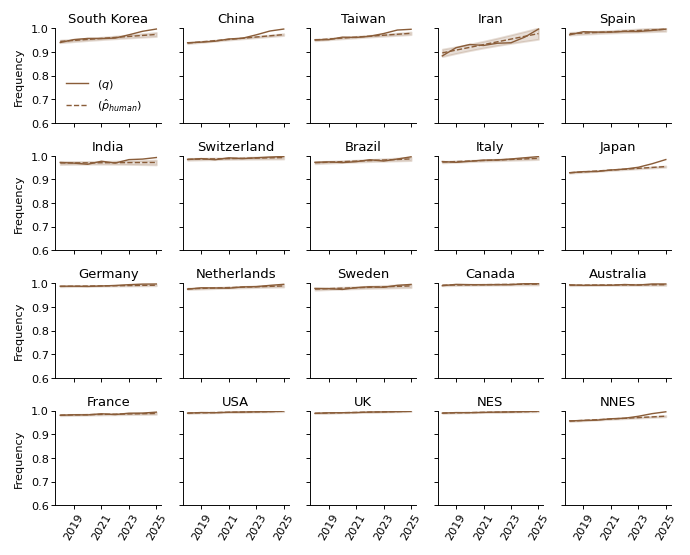

In [21]:
df_filtered = df[(df["section"] == "full") & (~df["country"].isin(exclude))]

countries = df_filtered["country"].unique()
n = len(countries)

ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(ncols, nrows),
    sharex=True,
    sharey=True,
    layout="constrained",
)
axes = axes.flatten()

for i, country in enumerate(countries_in_order):
    ax = axes[i]
    sub = df_filtered[df_filtered["country"] == country].sort_values("time")

    ax.plot(
        sub["time"],
        sub["frequency"],
        color=colors["full"],
        label="($q$)",
    )

    ax.plot(
        sub["time"],
        sub["projection"],
        # yerr=sub["regression se"],
        color=colors["full"],
        linestyle="--",
        label="($\\hat{p}_{human}$)",
    )

    ax.fill_between(
        sub["time"],
        sub["projection"] - sub["regression se"],
        sub["projection"] + sub["regression se"],
        alpha=0.2,
        color=colors["full"],
    )

    # Title
    ax.set_title(country)

    ax.set_ylim([0.6, 1])
    ax.set_xticks(range(2019, 2026, 2))

    if i % ncols == 0:
        ax.set_ylabel("Frequency")
    if i >= ncols * (nrows - 1):
        ax.set_xticklabels(range(2019, 2026, 2), rotation=60)


axes[0].legend()

# plt.tight_layout()
plt.savefig(
    os.path.join(
        "../results/plots",
        BASELINE,
        VERSION,
        "countries_individual_freqs_{CUTOFF_VERSION}.png",
    ),
    dpi=300,
)
plt.show()